# Upper/lower binary time-data analysis

This notebook loads the per-initial-condition CSV files produced by the matching time-data Julia script.


In [62]:
import os
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("default")
plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.2,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 16,
})


def float_str(f):
    return str(float(f)).replace(".", "p")


In [63]:
# These controls mirror get_time_random_uppper_lower_binary_time_data.jl.
L_vals = [20000]
average_epsilon_c = 0.27035
average_epsilon_rate = 0.0003
p_val = 0.8
lower_div = 20
upper_epsilon_c = average_epsilon_c / (p_val + (1-p_val)/lower_div)
upper_epsilon_rate = average_epsilon_rate / (p_val + (1-p_val)/lower_div)
upper_epsilons = [round(upper_epsilon_c + i * upper_epsilon_rate, 6) for i in range(-3, 4)]
lower_epsilons = [round(upper_ep / lower_div, 6) for upper_ep in upper_epsilons]
p_vals = [p_val] * len(upper_epsilons)

# The plotted control variable is epsilon_bar = p epsilon_u + (1-p) epsilon_l.
control_vals = [round(p * upper + (1 - p) * lower, 6)
                for upper, lower, p in zip(upper_epsilons, lower_epsilons, p_vals)]
control_label = r"$\bar{\varepsilon}$"
model_label = "Time-Random Upper/Lower Binary"
time_prefact = 100
time_step = 20000
num_initial_conds = 3000
num_init_conds_offset = 0
initial_state_prob = 0.5
DATA_ROOT = Path("data/time_rand_window_binary/rho_per_time/IC1")
DATA_ROOT = Path("/Volumes/ExternalData/stavskya_mc/data/time_rand_window_binary/rho_per_time/IC1")
FIG_ROOT = Path("figs/time_random/time_rand_window_binary")
FIG_ROOT.mkdir(parents=True, exist_ok=True)


def sample_path(L_val, upper_ep, lower_ep, p_val, init_cond):
    upper_name, lower_name, p_name = map(float_str, (upper_ep, lower_ep, p_val))
    return DATA_ROOT / f"L{L_val}" / f"epsilonu{upper_name}" / f"epsilonl{lower_name}" / f"pval{p_name}" / (
        f"IC1_L{L_val}_epsilonu{upper_name}_epsilonl{lower_name}_pval{p_name}_"
        f"timepref{time_prefact}_timestep{time_step}_sample{init_cond}.csv"
    )


In [64]:
for i in range(len(lower_epsilons)):
    if lower_epsilons[i] == 0.016661:
        lower_epsilons[i] = 0.01666

list(zip(control_vals, upper_epsilons, lower_epsilons, p_vals))

[(0.26945, 0.332654, 0.016633, 0.8),
 (0.26975, 0.333025, 0.016651, 0.8),
 (0.27005, 0.333395, 0.01667, 0.8),
 (0.27035, 0.333765, 0.016688, 0.8),
 (0.27065, 0.334136, 0.016707, 0.8),
 (0.27095, 0.334506, 0.016725, 0.8),
 (0.27125, 0.334877, 0.016744, 0.8)]

In [65]:
# Load every available initial-condition trajectory and calculate mean and SEM.
mean_rhos = {}
sem_rhos = {}
time_vals = {}
loaded_counts = {}

for L_val in L_vals:
    for control_val, upper_ep, lower_ep, p_val in zip(control_vals, upper_epsilons, lower_epsilons, p_vals):
        trajectories = []
        times = None
        for init_cond in range(1 + num_init_conds_offset, num_initial_conds + 1 + num_init_conds_offset):
            filepath = sample_path(L_val, upper_ep, lower_ep, p_val, init_cond)
            if not filepath.exists():
                continue
            sample_df = pd.read_csv(filepath)
            if times is None:
                times = sample_df["time"].to_numpy()
            trajectories.append(sample_df["rho"].to_numpy())
        if not trajectories:
            print(filepath)
            raise FileNotFoundError(f"No trajectories found for L={L_val}, {control_label}={control_val}")
        trajectories = np.asarray(trajectories)
        key = (L_val, control_val)
        time_vals[key] = times
        mean_rhos[key] = trajectories.mean(axis=0)
        sem_rhos[key] = trajectories.std(axis=0, ddof=1) / np.sqrt(len(trajectories))
        loaded_counts[key] = len(trajectories)

loaded_counts


{(20000, 0.26945): 3000,
 (20000, 0.26975): 3000,
 (20000, 0.27005): 3000,
 (20000, 0.27035): 3000,
 (20000, 0.27065): 3000,
 (20000, 0.27095): 3000,
 (20000, 0.27125): 3000}

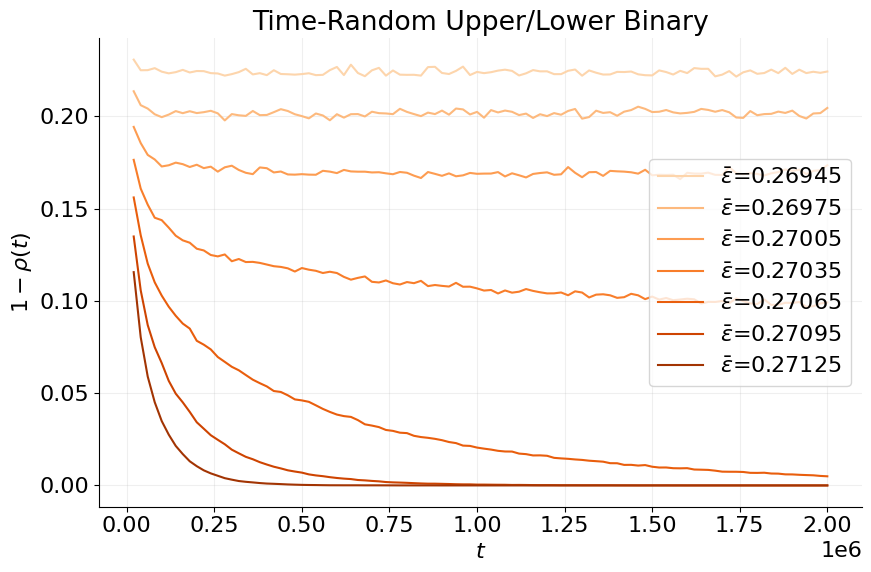

In [67]:
for L_val in L_vals:
    fig, ax = plt.subplots(figsize=(9, 6))
    cmap = plt.colormaps.get_cmap("Oranges").resampled(len(control_vals) + 3)
    for i, control_val in enumerate(control_vals):
        key = (L_val, control_val)
        ax.plot(time_vals[key], 1 - mean_rhos[key], color=cmap(i + 2), label=fr"{control_label}={control_val}")
    ax.set_title(model_label)
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$1 - \rho(t)$")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_ROOT / "rho_per_time.png", dpi=200)
    plt.show()


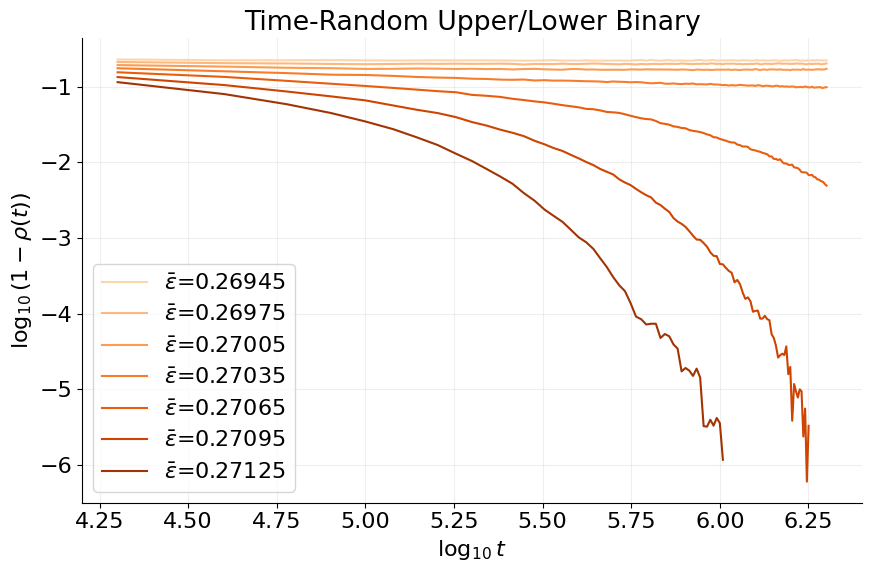

In [68]:
fig, ax = plt.subplots(figsize=(9, 6))
cmap = plt.colormaps.get_cmap("Oranges").resampled(len(control_vals) + 3)
for L_val in L_vals:
    for i, control_val in enumerate(control_vals):
        key = (L_val, control_val)
        positive = (time_vals[key] > 0) & (1 - mean_rhos[key] > 0)
        ax.plot(np.log10(time_vals[key][positive]), np.log10((1 - mean_rhos[key])[positive]),
                color=cmap(i + 2), label=fr"{control_label}={control_val}")
ax.set_title(model_label)
ax.set_xlabel(r"$\log_{10} t$")
ax.set_ylabel(r"$\log_{10}(1 - \rho(t))$")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_ROOT / "rho_per_time_log.png", dpi=200)
plt.show()


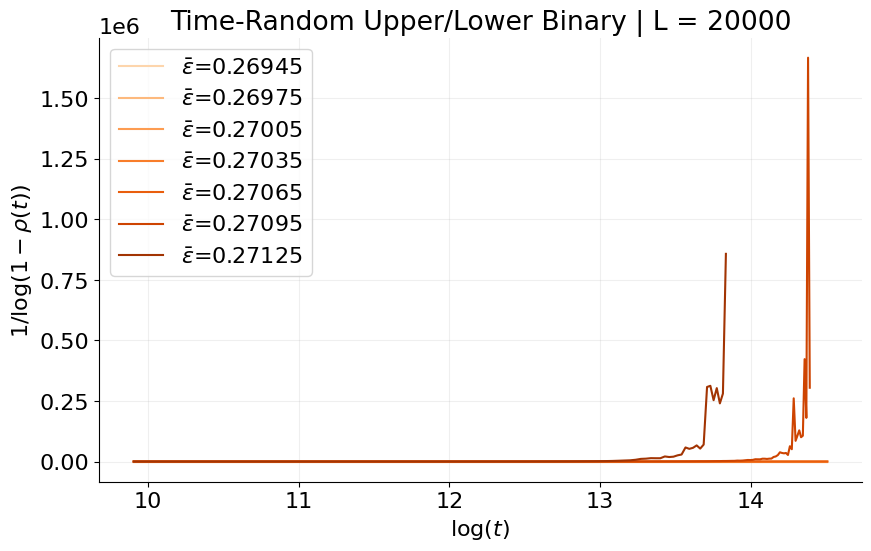

In [69]:
for L_val in L_vals:
    fig, ax = plt.subplots(figsize=(9, 6))
    cmap = plt.colormaps.get_cmap("Oranges").resampled(len(control_vals) + 3)
    for i, control_val in enumerate(control_vals):
        key = (L_val, control_val)
        positive = (time_vals[key] > 0) & (1 - mean_rhos[key] > 0)
        ax.plot(np.log(time_vals[key][positive]), 1/((1 - mean_rhos[key]))[positive],
                color=cmap(i + 2), label=fr"{control_label}={control_val}")
    ax.set_title(model_label + f" | L = {L_val}")
    ax.set_xlabel(r"$\log (t)$")
    ax.set_ylabel(r"$1/\log(1 - \rho(t))$")
    ax.legend()
    fig.tight_layout()
    # fig.savefig(FIG_ROOT / f"rho_per_time_logL{L_val}.png", dpi=200)
    plt.show()

alpha = 1.5747292622160445


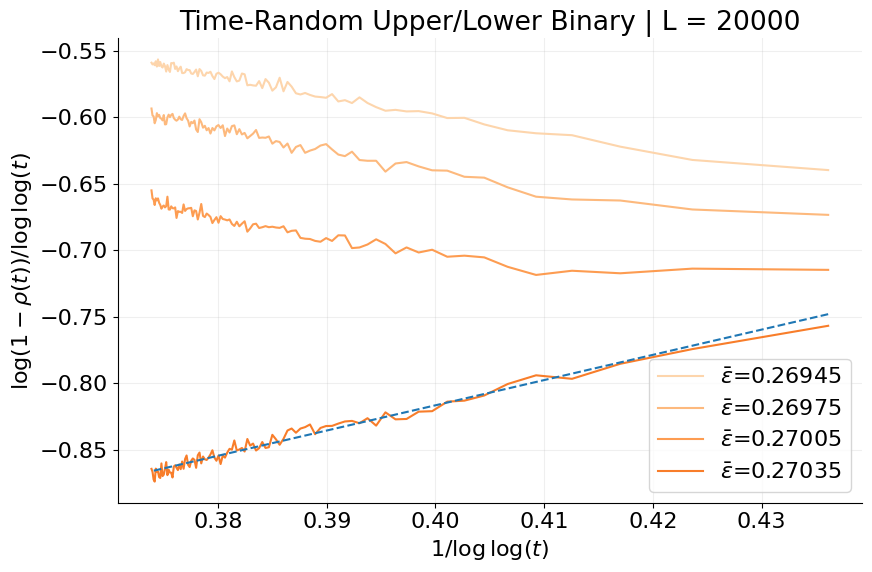

In [74]:
control_c = 0.27035
for L_val in L_vals:
    fig, ax = plt.subplots(figsize=(9, 6))
    cmap = plt.colormaps.get_cmap("Oranges").resampled(len(control_vals) + 3)
    for i, control_val in enumerate(control_vals[:-3]):
        key = (L_val, control_val)
        positive = (time_vals[key] > 0) & (1 - mean_rhos[key] > 0)
        X = 1/np.log(np.log(time_vals[key][positive]))
        ax.plot(X, np.log(((1 - mean_rhos[key]))[positive])*X,
                color=cmap(i + 2), label=fr"{control_label}={control_val}")
    crit_key = (L_val, control_c)
    X = 1/np.log(np.log(time_vals[crit_key][positive]))
    m,b = np.polyfit(X[0:100], (np.log(((1 - mean_rhos[crit_key]))[positive])*X)[0:100], 1)
    ax.plot(X, m * X + b, linestyle="--")
    print(f"alpha = {-b}")
    ax.set_title(model_label + f" | L = {L_val}")
    ax.set_xlabel(r"$1/\log \log (t)$")
    ax.set_ylabel(r"$\log(1 - \rho(t))/\log \log (t)$")
    ax.legend()
    fig.tight_layout()
    # fig.savefig(FIG_ROOT / f"rho_per_time_logL{L_val}.png", dpi=200)
    plt.show()

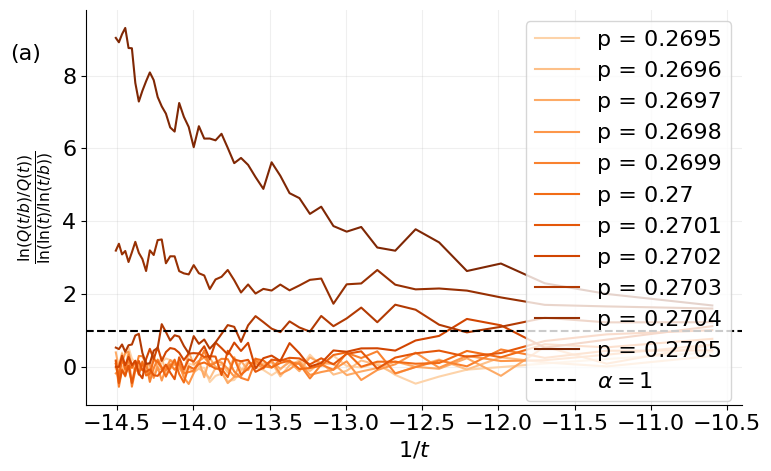

In [61]:
b = 2
alpha_guess = 1
for j, L in enumerate(L_vals):
    fig=plt.figure(figsize=(8,5))
    for i, control_val in enumerate(control_vals):
        if control_val in [0.47895]:
            continue
        c = cmap(i+3)
        key = (L, control_val)
        l_time_vals = [t * b for t in time_vals[key] if t*b <=max(time_vals[key])]
        data_to_plot = 1 - mean_rhos[key]
        data_to_plot_numerator1 = np.array([data_to_plot[(t//(b*time_step)) -1] for t in l_time_vals])
        data_to_plot_numerator2 = np.array([data_to_plot[(t//(time_step)) - 1] for t in l_time_vals])
        data_to_plot_denomenator1 = np.log(np.array(l_time_vals))
        data_to_plot_denomenator2 = np.log(np.array(l_time_vals)//b)
        data_to_plot = np.log(data_to_plot_numerator1/data_to_plot_numerator2) / np.log(data_to_plot_denomenator1/data_to_plot_denomenator2)
        plt.plot(
            np.log(1/np.array(l_time_vals)), 
            data_to_plot, 
            label = fr"p = {control_val}",
            # fmt='--',  
            # markersize=3,
            # marker = "o",
            # capsize=3,
            c=c
            )
    
    
    plt.axhline(alpha_guess, c = 'k', label=fr"$\alpha = {alpha_guess}$", linestyle ="--")
    # plt.title(fr"Time Random: $L = {L}$ $\|$ $a = {a_val}$")
    plt.text(0.03, 0.85, "(a)", fontsize=plt.rcParams["axes.labelsize"], transform=fig.transFigure)
    plt.xlabel(r"$1/t$")
    plt.ylabel(r"$\frac{\ln(Q(t/b)/Q(t))}{\ln(\ln(t)/\ln(t/b))}$")
    plt.legend()
    # plt.xlim((np.log(0.000005), np.log(0.0005)))
    # plt.ylim((0.01, 0.25))
    plt.tight_layout()
    # plt.savefig(f"figs/time_random/broad/broadstav_determining_ac_delta.png")
    plt.show()

In [ ]:
alpha_guess = 1.0
guess_nu_perp = 0.2
control_c = 0.27
# control_vals = [0.4938, 0.4933, 0.4913, 0.4918]
print(f"Beta: {alpha_guess*guess_nu_perp}")
for j, L in enumerate(L_vals):
    plt.figure(figsize=(8,5))
    for i, control_val in enumerate(control_vals):
        if control_val == control_c or i == 6:
            continue
        c = cmap(i+3)
        key = (L, control_val)
        l_time_vals = np.array([t for t in time_vals[key]])
        orig_data = (1 - mean_rhos[key])
        plt.plot(
            (np.log(l_time_vals)**(1/guess_nu_perp)*(control_val - control_c))[1:], 
            (orig_data * np.log(l_time_vals) ** alpha_guess)[1:], 
            label = fr"$p = {control_val}$",
            # fmt='--',  
            # markersize=3,
            # marker = "o",
            # capsize=3,
            c=c
            )
    
    # plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
    # plt.title(fr"Time Random $a = {a_val}$: $L = {L}$ $\|$ $\delta = {delta_guess}$ $\|$ $\nu_{{\|}} = {guess_nu_par}$")
    plt.text(0.02, 0.85, "(b)", fontsize=plt.rcParams["axes.labelsize"], transform=fig.transFigure)
    plt.xlabel(r"$\ln(t)^{1/\nu_{\perp}}(\varepsilon - \varepsilon_c)$")
    plt.ylabel(r"$(1 - \rho)\ln(t)^\alpha$")
    plt.legend()
    # plt.xlim(0.0003, 0.16)
    # plt.ylim(0.3, 1.1)

    plt.tight_layout()
    # plt.savefig(f"figs/time_random/broad/broadstav_determining_nupar.png")
    plt.show()